## Importing Libraries

In [213]:
import pandas as pd
import numpy as np
import os, math
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler,StandardScaler

## Importing Dataset

In [214]:
df1 = pd.read_csv('bodyPerformance.csv')

## Data pre-processing & Visualizations

In [215]:
df1.sample(5)

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
6524,25.0,M,184.2,87.1,24.8,66.0,122.0,36.0,1.0,25.0,207.0,D
6661,32.0,F,154.0,53.2,24.5,67.0,108.0,29.1,20.7,15.0,156.0,D
7118,25.0,M,175.8,84.6,28.8,84.0,146.0,36.8,15.2,37.0,162.0,D
4558,60.0,F,155.4,49.6,29.0,62.0,101.0,26.3,21.5,26.0,110.0,B
1348,27.0,M,180.9,82.3,23.2,95.0,152.0,49.6,15.4,46.0,225.0,C


In [216]:
df1.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [217]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  object 
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  object 
dtypes: float64(10), object(2)
memory usage: 1.2+ MB


In [218]:
df1.describe()

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm
count,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000
mean,36.775106,168.559807,67.447316,23.240165,78.796842,130.234817,36.963877,15.209268,39.771224,190.129627
std,13.625639,8.426583,11.949666,7.256844,10.742033,14.713954,10.624864,8.456677,14.276698,39.868000
min,21.000000,125.000000,26.300000,3.000000,0.000000,0.000000,0.000000,-25.000000,0.000000,0.000000
25%,25.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,10.900000,30.000000,162.000000
50%,32.000000,169.200000,67.400000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000
75%,48.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.700000,50.000000,221.000000
max,64.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,213.000000,80.000000,303.000000


### Checking missing values

In [219]:
df1.isnull()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
13388,False,False,False,False,False,False,False,False,False,False,False,False
13389,False,False,False,False,False,False,False,False,False,False,False,False
13390,False,False,False,False,False,False,False,False,False,False,False,False
13391,False,False,False,False,False,False,False,False,False,False,False,False


In [221]:
df1.isnull().sum()


age                        0
gender                     0
height_cm                  0
weight_kg                  0
body fat_%                 0
diastolic                  0
systolic                   0
gripForce                  0
sit and bend forward_cm    0
sit-ups counts             0
broad jump_cm              0
class                      0
dtype: int64

no missing values found 

In [222]:
df1.dtypes

age                        float64
gender                      object
height_cm                  float64
weight_kg                  float64
body fat_%                 float64
diastolic                  float64
systolic                   float64
gripForce                  float64
sit and bend forward_cm    float64
sit-ups counts             float64
broad jump_cm              float64
class                       object
dtype: object

### Converting categorical data to numerical data (Encoding)

In [223]:
#defining a function to convert category of data

def change(df,col_name):
    df[col_name] = pd.Categorical(df[col_name])
    df[col_name+"_cat"] = df[col_name].cat.codes
    df.drop(columns=[col_name],inplace=True)

In [224]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
gender_num = le.fit_transform(df1['gender'])
class_num = le.fit_transform(df1['class'])

print(gender_num)

[1 1 1 ... 1 0 1]


In [225]:
df1['gender'] = gender_num
df1.head()

# Male - 1
# Female - 0

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,1,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,1,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [226]:
df1['class'].value_counts()

class
C    3349
D    3349
A    3348
B    3347
Name: count, dtype: int64

In [227]:
df1['class'] = class_num
df1['class'].value_counts()



class
2    3349
3    3349
0    3348
1    3347
Name: count, dtype: int64

Class A - 0
Class B - 1
Class C - 2
Class D - 3

### Visualizations

#### Bar Plots

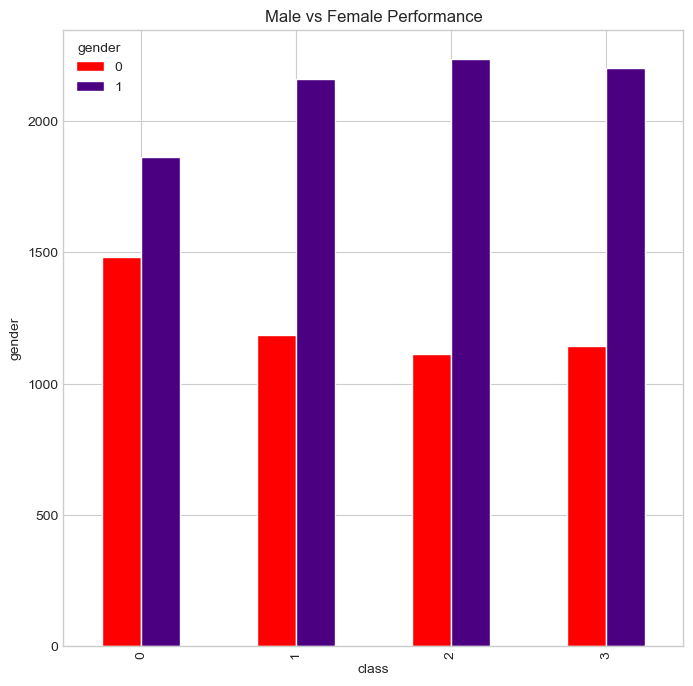

In [228]:
#Male vs Female performance
df1.groupby(["class","gender"]).size().unstack(level=1).plot(kind="bar",figsize=(8,8),ylabel="gender",color=["red","indigo"],title="Male vs Female Performance");

#### Donut Chart

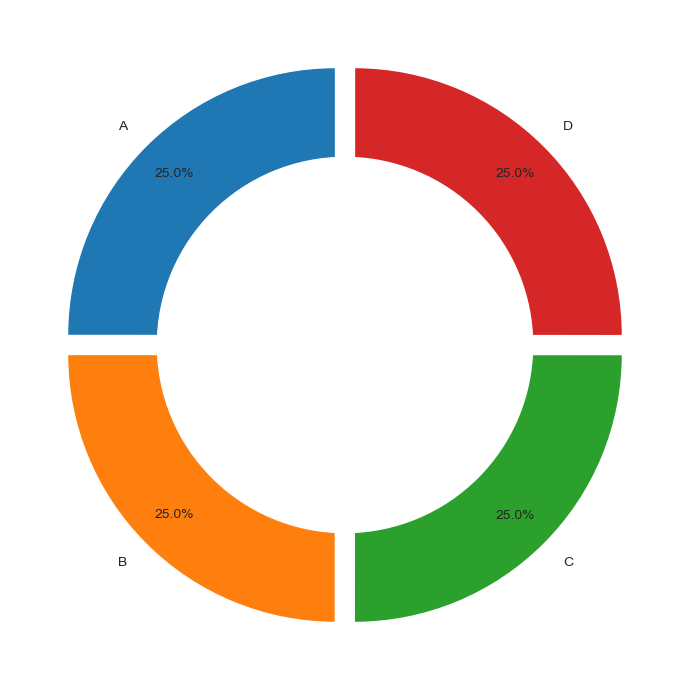

In [229]:


labels = ['A', 'B', 'C', 'D']
sizes = [3348, 3347, 3349, 3349]
#colors
#colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']
#explsion
explode = (0.05,0.05,0.05,0.05)
 
plt.figure(figsize = (7,7))

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, pctdistance=0.85, explode = explode)
#draw circle
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
# Equal aspect ratio ensures that pie is drawn as a circle
#ax1.axis('equal')  
plt.tight_layout()
plt.show()

#### Pie Chart 

In [230]:
df1['gender'].value_counts()

gender
1    8467
0    4926
Name: count, dtype: int64

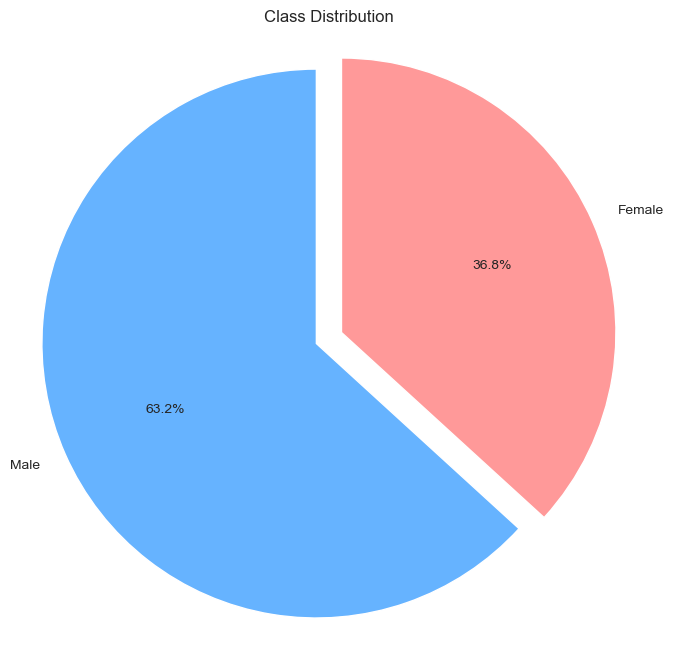

In [231]:
dist = [8467, 4926]
my_labels = 'Male', 'Female'
colors = ['#66b3ff', '#ff9999']
explode = (0, 0.1)
plt.figure(figsize = (8,8))
plt.pie(dist,labels=my_labels,autopct='%1.1f%%', colors=colors, explode=explode, startangle=90)
plt.title('Class Distribution')
plt.axis('equal')
plt.show()

#### Correlation Bar Plot 

renaming column 'class' to 'Class' because class is a keyword in python

In [232]:
df1.rename(columns={'class':'Class'}, inplace=True)



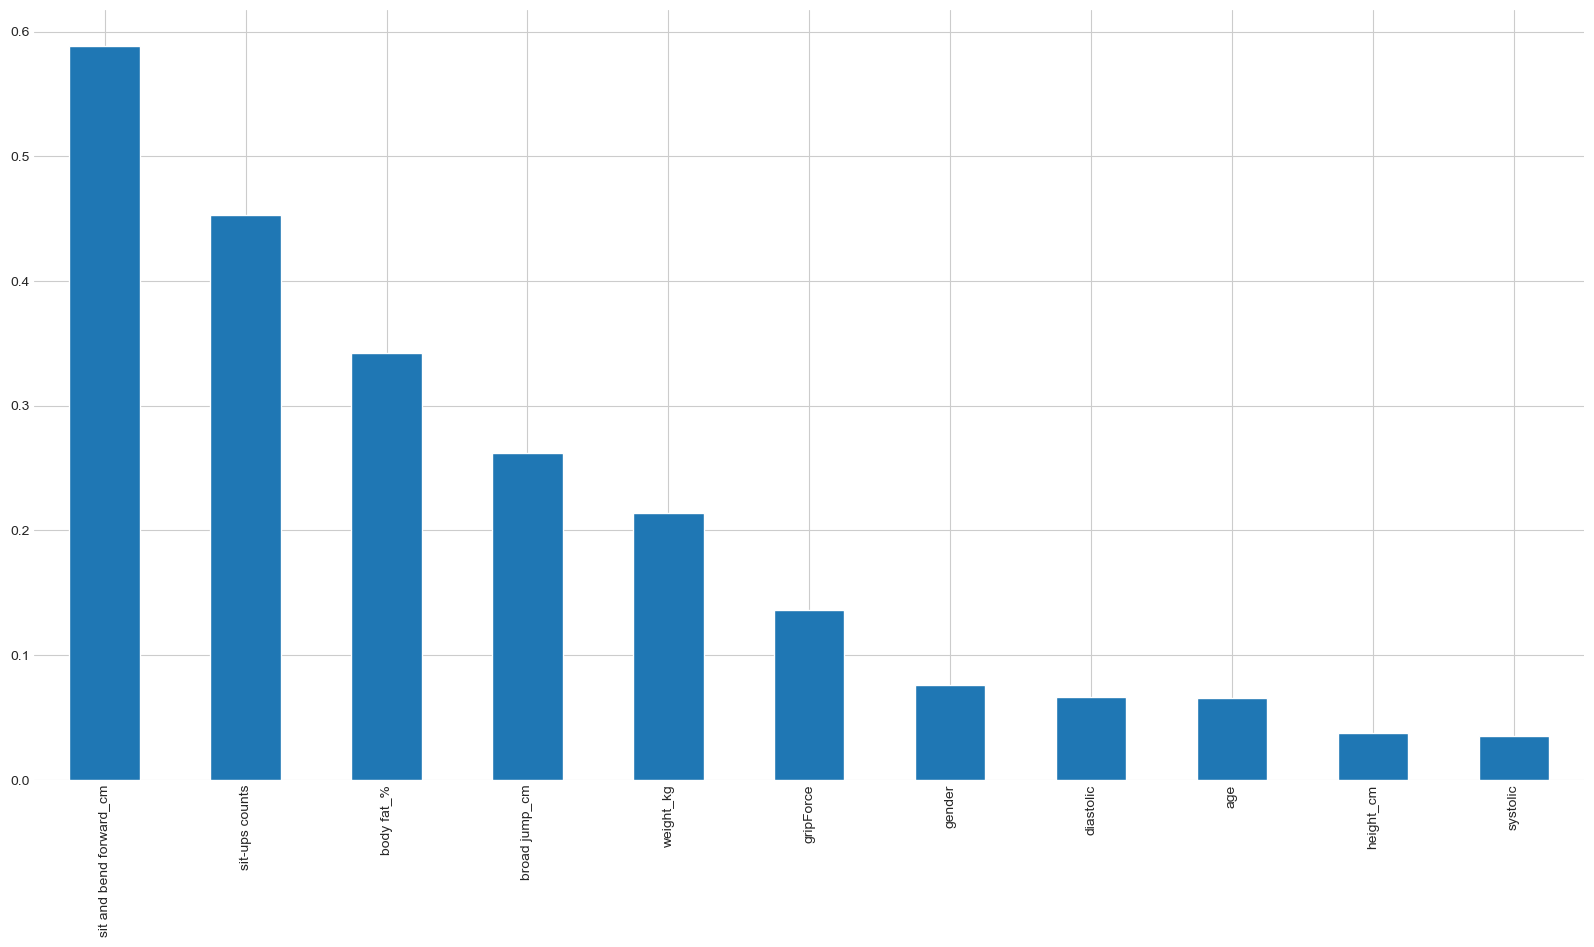

In [233]:
def despine():
    sns.despine(top=1,bottom=1,right=1,left=1)

df1.corr().Class.sort_values(ascending=False)[1:].abs().sort_values(ascending=False).plot(kind='bar',figsize=(20,10),alpha=1)

#df1.corr().plot(kind='bar',figsize=(20,10), alpha=1)
despine()

We conclude that the most important features (in order) are: sit and bend forward, sit ups counts, body fat, broadjump and weight

#### Correlation Matrix

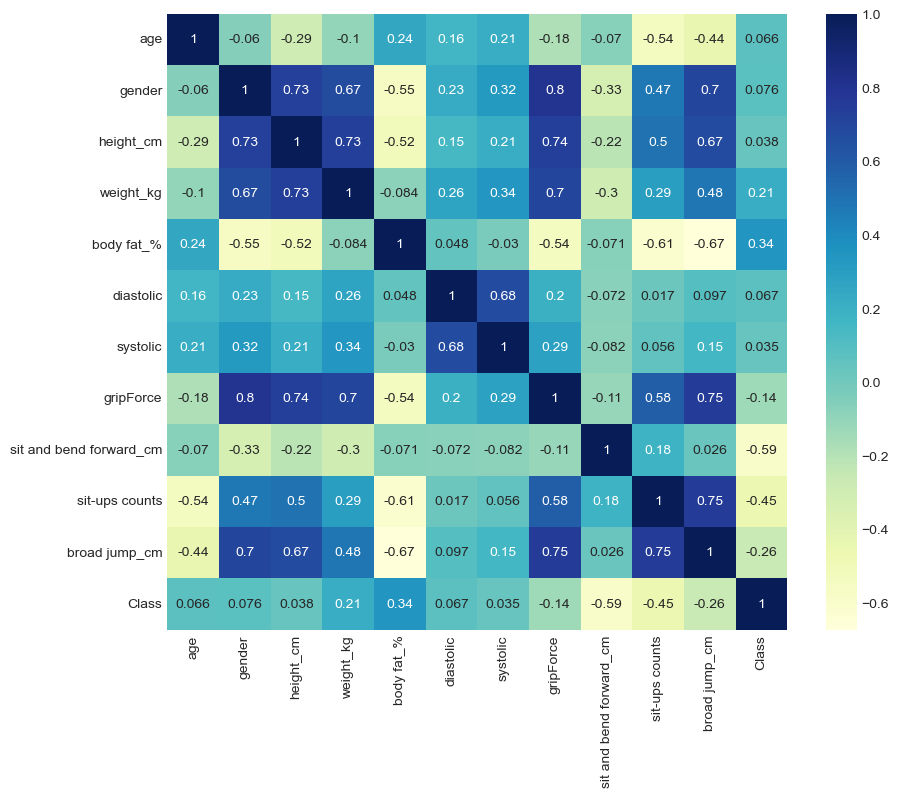

In [234]:
fig,ax = plt.subplots(figsize=(10,8))
sns.heatmap(df1.corr(),cmap="YlGnBu",annot=True,ax=ax);

#### Scatter Plot

In [235]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

def plot_scatter(df, col1, col2, target, cmap="viridis"):
    fig, ax = plt.subplots(figsize=(10,8))
    scatter = ax.scatter(df[col1], df[col2], c=df[target], cmap=cmap)
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.title(f"{col1} vs {col2}")
    plt.show()

In [236]:
df1.columns

Index(['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic',
       'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts',
       'broad jump_cm', 'Class'],
      dtype='object')

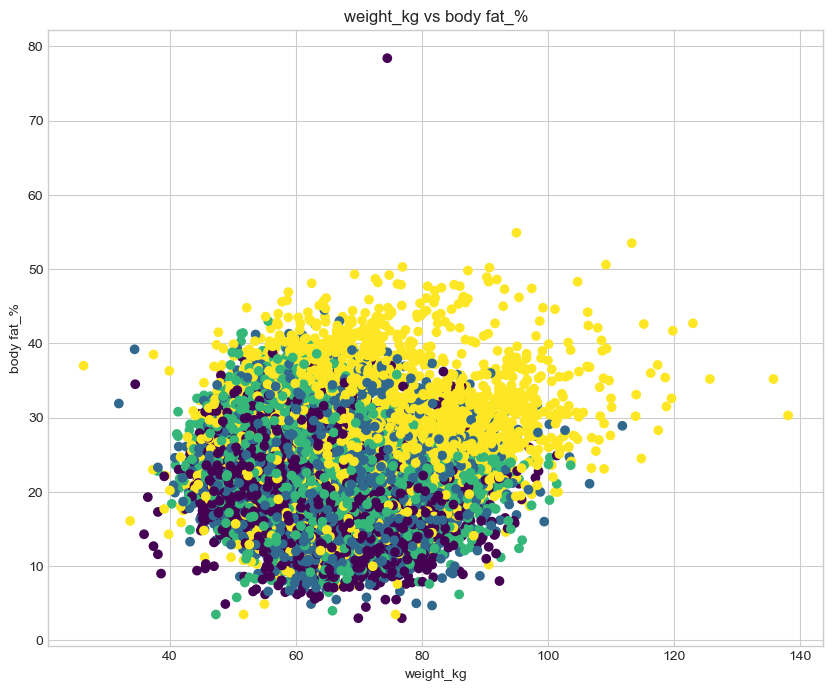

In [237]:
plot_scatter(df1,"weight_kg","body fat_%","Class")

Lesser the body_fat% with respect to weight, Fitter the person is 

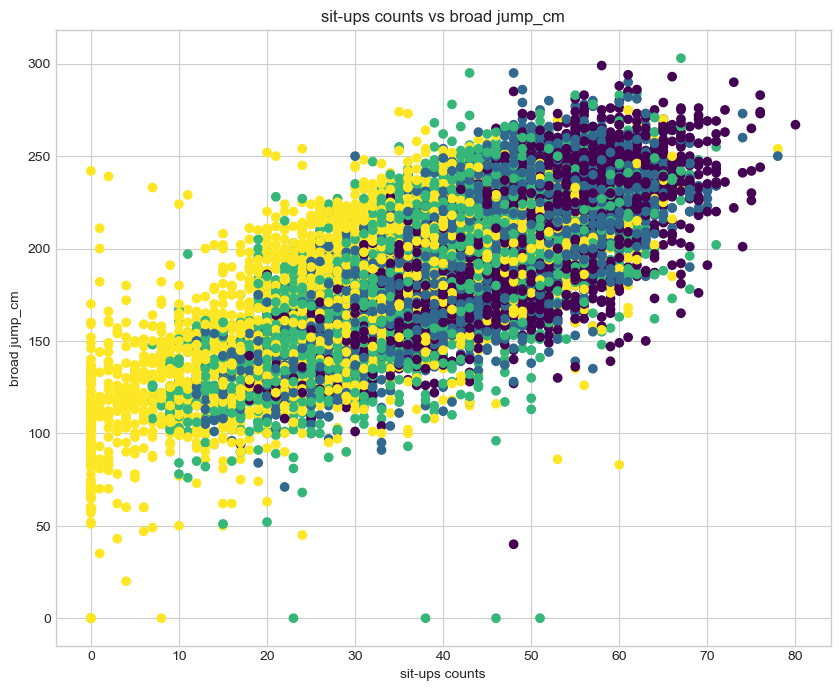

In [238]:
plot_scatter(df1,"sit-ups counts","broad jump_cm","Class")

More the sit-ups counts & broad jump distance, Fitter the person is

### Outliers Detection 

In [239]:
df1.columns

Index(['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic',
       'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts',
       'broad jump_cm', 'Class'],
      dtype='object')

<Axes: >

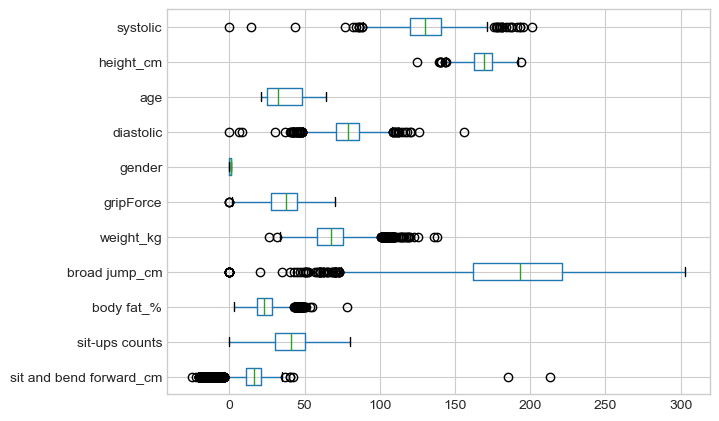

In [240]:
corr = df1.corr(numeric_only=True)

fullset = corr['Class'].abs().sort_values(ascending=False).iloc[1:].index.tolist()

df1[fullset].boxplot(figsize=(7,5), vert=False)

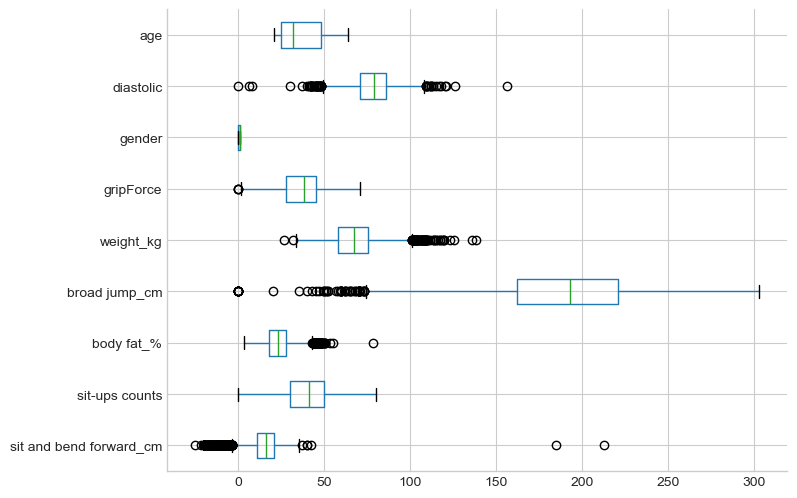

In [241]:
top_features = df1.corr()['Class'].abs().sort_values(ascending=False)[1:10].index

df1[top_features].boxplot(vert=False, figsize=(8,6))
sns.despine()

We see that the following features have outliers:
[systolic]
[height_cm]
[diastolic]
[weight_kg]
[broad jump_cm]
[body fat_%]
[sit and bend forward_cm]

In [242]:
# defining a function to get the outliers

def outlier(df,lst,fence=1.5):
    outlier_index=[]
    for col in lst:
        q1,q3=np.percentile(df[col],25), np.percentile(df[col],75)
        iqr=q3-q1
        outlier_index.extend(df[(df[col]<q1-fence*iqr)|(df[col]>q3+fence*iqr)].index)
    return list(set(outlier_index))

In [243]:
# calling the outlier function
lst = ['height_cm', 'weight_kg', 'body fat_%', 'diastolic',
       'systolic', 'sit and bend forward_cm',
       'broad jump_cm']
outlier_index = outlier(df1, lst, fence=3)
print(f'We have {len(outlier_index)} observations as outliers, we will drop them')

We have 31 observations as outliers, we will drop them


In [244]:
df1.shape

(13393, 12)

### Outliers Removal 

In [245]:
df1 = df1.drop(index=outlier_index)

In [246]:
df1.shape

(13362, 12)

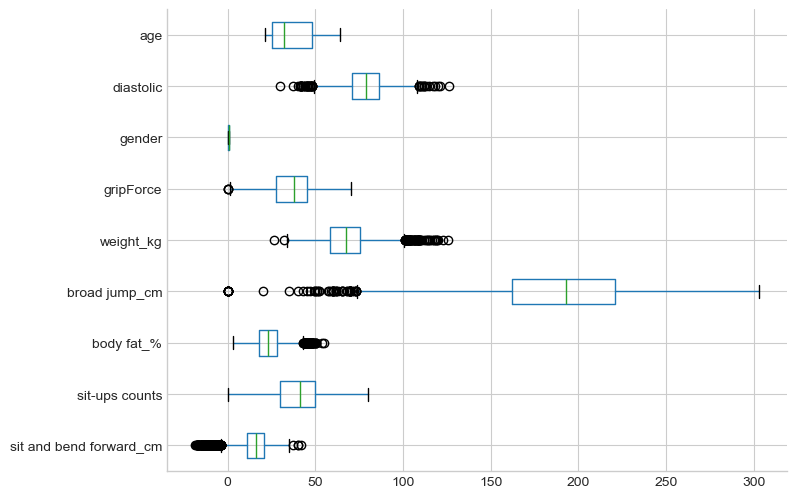

In [247]:
top_features = df1.corr()['Class'].abs().sort_values(ascending=False)[1:10].index

df1[top_features].boxplot(vert=False, figsize=(8,6))

sns.despine()

We observe that the outliers have been resolved

### Scaling and Normalization

In [248]:
df2 = df1

In [249]:
# Standard Scaling 

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

X = df1.drop(columns=["Class"])
y = df1["Class"]


# didnt include [gender] feature in scaling because it is already binary. 
scale_columns = ["age","height_cm","weight_kg","body fat_%",
              "diastolic","systolic","gripForce","sit and bend forward_cm",
              "sit-ups counts","broad jump_cm"]
scaler = StandardScaler()
transformer = ColumnTransformer([
    ("scaler",scaler,scale_columns)
])
transform_X = transformer.fit_transform(X)
transform_X

array([[-0.71753648,  0.44491098,  0.65529341, ...,  0.3936682 ,
         1.41643642,  0.67346016],
       [-0.86430718, -0.42259686, -0.97678444, ...,  0.13272348,
         0.92575318,  0.97455856],
       [-0.42399508,  1.31241881,  0.88700816, ..., -0.4015919 ,
         0.64536276, -0.22983502],
       ...,
       [ 0.16308771,  1.02721075,  1.09689472, ...,  0.14514942,
         0.36497234,  0.97455856],
       [ 1.99772143, -2.66861028, -0.81727066, ..., -0.74951819,
        -2.78941987, -2.88953752],
       [-0.20383904, -0.54143355, -0.11205184, ..., -1.01046291,
         0.78555797, -0.25492656]])

### Splitting dataset into training and testing 

In [250]:
from sklearn.model_selection import train_test_split
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=.2,random_state=0,stratify=df1.Class)
print(f"Train size: {Xtrain.shape[0]} ; Validation/Test size: {Xtest.shape[0]}")

Train size: 10689 ; Validation/Test size: 2673


## Modelling 

### KNN

Finding the optimum value of k by plotting a groph between Error Rate and K values

In [251]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

error_rate = []

for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(Xtrain, ytrain)
    pred_i = knn.predict(Xtest)
    error_rate.append(np.mean(pred_i != ytest))

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(range(1,40),error_rate,color='blue', linestyle='dashed',marker='o',markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
req_k_value = error_rate.index(min(error_rate))+1
print("Minimum error:-",min(error_rate),"at K =",req_k_value)

Thus k=34 is the optimum value of k

In [ ]:
from sklearn.neighbors import KNeighborsClassifier  
knn_classifier= KNeighborsClassifier(n_neighbors=34, metric='minkowski', p=2 )  
knn_classifier.fit(Xtrain, ytrain) 
y_pred= knn_classifier.predict(Xtest)

In [ ]:
#Creating the Confusion matrix  
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print("KNN - 34 neighbors Accuracy score and Confusion matrix")
print(accuracy_score(y_pred,ytest))
print(confusion_matrix(ytest, y_pred))
print("-------------------------")

<b>Accuracy of our KNN-Classifier = 59.97%</b>

In [255]:
from sklearn.metrics import classification_report

print(classification_report(ytest,knn_classifier.predict(Xtest)))

              precision    recall  f1-score   support

           0       0.61      0.82      0.70       669
           1       0.45      0.46      0.45       669
           2       0.53      0.48      0.50       670
           3       0.91      0.64      0.75       665

    accuracy                           0.60      2673
   macro avg       0.62      0.60      0.60      2673
weighted avg       0.62      0.60      0.60      2673



<Axes: >

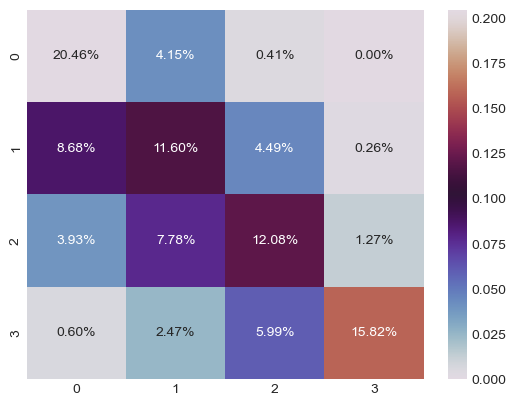

In [256]:
cf_matrix = confusion_matrix(ytest,knn_classifier.predict(Xtest))
sns.heatmap(cf_matrix/np.sum(cf_matrix),annot=True,annot_kws={"size":10},cmap='twilight',fmt='.2%')

### Random Forest

In [257]:
from sklearn.ensemble import RandomForestClassifier
random_classifier = RandomForestClassifier(n_estimators = 500, random_state = 100)
random_classifier.fit(Xtrain, ytrain)
y_pred = random_classifier.predict(Xtest)

In [258]:
print(f"train score: {random_classifier.score(Xtrain,ytrain):.4f}")

train score: 1.0000


In [259]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print("Random Forest Accuracy score and Confusion matrix")
print(accuracy_score(y_pred,ytest))
print(confusion_matrix(ytest, y_pred))
print("-------------------------")

Random Forest Accuracy score and Confusion matrix
0.7500935278713057
[[568  97   4   0]
 [133 427  90  19]
 [ 56 125 455  34]
 [  9  33  68 555]]
-------------------------


As we saw train score was 100 thus overfitting, so implementing cross-validation for random forest

In [260]:

# automatic nested cross-validation for random forest
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
# create dataset
#X, y = make_classification(n_samples=1000, n_features=20, random_state=1, n_informative=10, n_redundant=10)
# configure the cross-validation procedure
cv_inner = KFold(n_splits=3, shuffle=True, random_state=1)
# define the model
model = RandomForestClassifier(random_state=100)
# define search space
space = dict()
space['n_estimators'] = [500]
space['max_features'] = [11]
# define search
search = GridSearchCV(model, space, scoring='accuracy', n_jobs=1, cv=cv_inner, refit=True)
# configure the cross-validation procedure
cv_outer = KFold(n_splits=10, shuffle=True, random_state=1)
# execute the nested cross-validation
scores = cross_val_score(search, X, y, scoring='accuracy', cv=cv_outer, n_jobs=-1)
# report performance
print('Accuracy: %.3f (%.3f)' % (mean(scores), std(scores)))

Exception ignored in: <function ResourceTracker.__del__ at 0x10604dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Accuracy: 0.742 (0.011)


<b>Accuracy of our Random Forest Classifier with nested cross-validation = 74.3%</b>

### SVM 

In [261]:
from sklearn.svm import SVC
svc = SVC()
svc.fit(Xtrain, ytrain)
y_pred = svc.predict(Xtest)
print('Model accuracy score with default hyperparameters: {0:0.4f}'. format(accuracy_score(ytest, y_pred)))

Model accuracy score with default hyperparameters: 0.6184


In [262]:
linear_svc=SVC(kernel='linear', C=100.0) 
linear_svc.fit(Xtrain,ytrain)
y_pred_test=linear_svc.predict(Xtest)
print('Model accuracy score with linear kernel and C=100.0 : {0:0.4f}'. format(accuracy_score(y_test, y_pred_test)))

Exception ignored in: <function ResourceTracker.__del__ at 0x107169bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1101f9bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102829bc0>
Traceback (most recent call last

NameError: name 'y_test' is not defined

In [ ]:
linear_svc=SVC(kernel='linear', C=100.0) 
linear_svc.fit(X_train,y_train)
y_pred_test=linear_svc.predict(X_test)
print('Model accuracy score with linear kernel and C=100.0 : {0:0.4f}'. format(accuracy_score(y_test, y_pred_test)))

In [ ]:
poly_svc=SVC(kernel='poly',C=100.0) 
poly_svc.fit(X_train,y_train)
y_pred=poly_svc.predict(X_test)
print('Model accuracy score with poly kernel and C=100.0 : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

In [ ]:
rbf_svc=SVC(kernel='rbf',C=100.0) 
rbf_svc.fit(X_train,y_train)
y_pred=rbf_svc.predict(X_test)
print('Model accuracy score with rbf kernel and C=100.0 : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

In [ ]:
from sklearn.metrics import plot_confusion_matrix

matrix = plot_confusion_matrix(rbf_svc, X_test, y_test,
                                 cmap=plt.cm.Blues,
                                 normalize='true')
plt.title('Confusion matrix for RBF SVM')
plt.show(matrix)
plt.show()

In [ ]:
from sklearn.decomposition import PCA
from mlxtend.plotting import plot_decision_regions

clf = rbf_svc
pca = PCA(n_components = 2)
X_train2 = pca.fit_transform(X_train)
clf.fit(X_train2, y_train)
plot_decision_regions(X_train2, y_train, clf=clf, legend=2)

plt.xlabel(X.columns[0], size=14)
plt.ylabel(X.columns[1], size=14)
plt.title('SVM Decision Region Boundary', size=16)

In [ ]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X_test, y_test, clf=rbf_svc, legend=2)
plt.show()

In [ ]:
# create a mesh to plot in
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# title for the plots
titles = ['SVC with default parameters',
          'SVC with Linear kernel',
          'SVC with polynomial kernel',
          'SVC with RBF kernel']


for i, clf in enumerate((svc, linear_svc, poly_svc, rbf_svc)):
    # Plot the decision boundary. For that, we will assign a color to each
    # point in the mesh [x_min, x_max]x[y_min, y_max].
    plt.subplot(2, 2, i + 1)
    plt.subplots_adjust(wspace=0.4, hspace=0.4)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

    # Plot also the training points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm)
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.title(titles[i])

plt.show()

In [ ]:
# Get support vector indices
support_vector_indices = rbf_svc.support_
#print(support_vector_indices)

In [ ]:
# Get number of support vectors per class
support_vectors_per_class = rbf_svc.n_support_
print(support_vectors_per_class)

In [ ]:
# Get support vectors themselves
support_vectors = rbf_svc.support_vectors_

# Visualize support vectors
plt.scatter(X_train[:,0], X_train[:,1])
plt.scatter(support_vectors[:,0], support_vectors[:,1], color='red')
plt.title('Linearly separable data with support vectors')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [ ]:
from matplotlib.colors import ListedColormap

def plot_decision_regions(X,y,classifier,test_idx=None,resolution=0.02):
    
    # Initialise the marker types and colors
    markers = ('s','x','o','^','v')
    colors = ('red','blue','lightgreen','gray','cyan')
    color_Map = ListedColormap(colors[:len(np.unique(y))]) #we take the color mapping correspoding to the 
                                                            #amount of classes in the target data
    
    # Parameters for the graph and decision surface
    x1_min = X[:,0].min() - 1
    x1_max = X[:,0].max() + 1
    x2_min = X[:,1].min() - 1
    x2_max = X[:,1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min,x1_max,resolution),
                           np.arange(x2_min,x2_max,resolution))
    
    Z = classifier.predict(np.array([xx1.ravel(),xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    
    plt.contour(xx1,xx2,Z,alpha=0.4,cmap = color_Map)
    plt.xlim(xx1.min(),xx1.max())
    plt.ylim(xx2.min(),xx2.max())
    
    # Plot samples
    X_test, Y_test = X[test_idx,:], y[test_idx]
    
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x = X[y == cl, 0], y = X[y == cl, 1],
                    alpha = 0.8, c = color_Map(idx),
                    marker = markers[idx], label = cl
                   )

<b>Best Accuracy of our SVM-Classifier is with RBF kernel = 95%</b>

### Gaussian Naive Bayes Classifier

In [ ]:
from sklearn.naive_bayes import GaussianNB
Gaus_classifier = GaussianNB()
Gaus_classifier.fit(Xtrain, ytrain)
y_pred = Gaus_classifier.predict(Xtest)

In [ ]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print("Gaussian NB - Accuracy score and Confusion matrix")
print(accuracy_score(y_pred,ytest))
print(confusion_matrix(ytest, y_pred))
print("-------------------------")

<b>Accuracy of our Gaussian NB-Classifier = 55.14%</b>

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(ytest,Gaus_classifier.predict(Xtest)))

In [ ]:
cf_matrix = confusion_matrix(ytest,Gaus_classifier.predict(Xtest))
sns.heatmap(cf_matrix/np.sum(cf_matrix),annot=True,annot_kws={"size":10},cmap='twilight',fmt='.2%')